In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2002 - loss: 2.7644 - val_accuracy: 0.2601 - val_loss: 2.4059
Epoch 2/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2152 - loss: 2.3039 - val_accuracy: 0.2586 - val_loss: 2.2435
Epoch 3/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2317 - loss: 2.1957 - val_accuracy: 0.2601 - val_loss: 2.1795
Epoch 4/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2455 - loss: 2.1321 - val_accuracy: 0.2661 - val_loss: 2.1349
Epoch 5/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2530 - loss: 2.0970 - val_accuracy: 0.2377 - val_loss: 2.0987
Epoch 6/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2463 - loss: 2.0820 - val_accuracy: 0.2780 - val_loss: 2.0605
Epoch 7/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2515 - loss: 2.0550 - val_accuracy: 0.2631 - val_loss: 2.0420
Epoch 8/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2597 - loss: 2.0317 - val_accuracy: 0.2347 - val_

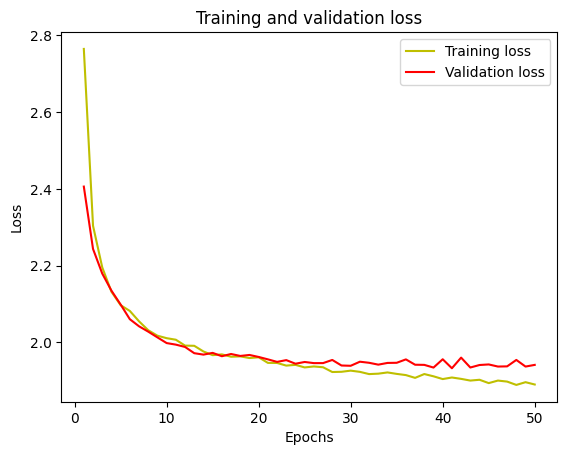

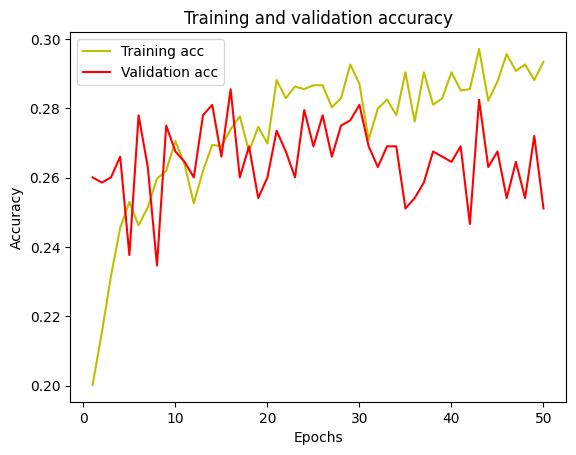

              precision    recall  f1-score   support

           2       0.00      0.00      0.00         5
           3       0.19      0.27      0.22        11
           4       0.42      0.15      0.22        33
           5       0.36      0.55      0.44        47
           6       0.41      0.31      0.35        98
           7       0.36      0.48      0.41       113
           8       0.31      0.36      0.34       127
           9       0.20      0.36      0.25       107
          10       0.24      0.23      0.24        95
          11       0.14      0.03      0.05        66
          12       0.09      0.10      0.09        39
          13       0.00      0.00      0.00        26
          14       0.11      0.06      0.07        18
          15       0.33      0.14      0.20        14
          16       0.12      0.10      0.11        10
          17       0.00      0.00      0.00         5
          18       0.00      0.00      0.00         8
          19       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/260410_202434919/abalone.csv'

df = pd.read_csv(path)
le = LabelEncoder()
df['Sex_encoded'] = le.fit_transform(df['Sex'])

X = df.drop(['Sex', 'Rings', 'id'], axis=1)
y = df['Rings']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#. Y 원-핫 인코딩
Y = pd.get_dummies(y).values

X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=0)

model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(Y.shape[1], activation="softmax") # 변경
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy", # 변경
    metrics=["accuracy"]
)

history = model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=16, verbose=1)

y_pred = model.predict(X_test)
y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

import matplotlib.pyplot as plt
import seaborn as sns

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))